# Weekly Project 04 - Multiple View Geometry 2

## Stereo camera calibration

This week you'll be provided with a set of stereo images, and your task is to undistort and rectify the images, such that they can be used with the stereo depth reconstruction you made on day 6. You are still not allowed to use opencv functions for block matching/template matching, however you are free to use opencv when undistorting the images. It is recommended that you finish the exercises from Monday before continuing with the weekly project.

The image sets are found in the `data/` folder. Start with `data/rs/` and move on to `data/mynteye/` once you have it working. The physical dimensions of each square of the pattern are 33.6 x 33.6 mm.

## Weekly Project 04 - Start Here

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import glob

nb_vertical = 9
nb_horizontal = 6

objp = np.zeros((nb_horizontal*nb_vertical, 3), np.float32)
objp[:, :2] = np.mgrid[0:nb_vertical, 0:nb_horizontal].T.reshape(-1, 2) * 33.6  # square size in mm

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [10]:
# From weekly project 03
def sad(image1, image2):
    """Sum of absolute differences between two equal-sized images."""
    if image1.shape != image2.shape:
        raise ValueError(f"Shapes differ: {image1.shape} vs {image2.shape}")
    # uint8 subtraction wraps around (e.g. 10 - 20 = 246), so cast to a signed type first
    diff = image1.astype(np.int32) - image2.astype(np.int32)
    return int(np.sum(np.abs(diff)))


def find_best_match(template, span):
    """Slide template left to right along span.

    Returns the best x (left edge of the window) and the SAD score at every x.
    """
    t_h, t_w = template.shape
    s_h, s_w = span.shape
    if t_h != s_h:
        raise ValueError(f"Heights differ: template {t_h} vs span {s_h}")
    if t_w > s_w:
        raise ValueError(f"Template width {t_w} is larger than span width {s_w}")
    scores = []
    # The last valid left edge is s_w - t_w, hence the + 1
    for x in range(s_w - t_w + 1):
        window = span[:, x:x + t_w]
        scores.append(sad(template, window))

    scores = np.array(scores)
    best_x = int(np.argmin(scores))
    return best_x, scores


def compute_disparity_map(left, right, block_size=7, max_disparity=64):
    """Block matching: for every block_size x block_size template in left,
    find the best match in the same rows of right using find_best_match.

    The disparity is stored at the template's center pixel. Border pixels
    that no template is centered on stay 0.
    """
    if left.shape != right.shape:
        raise ValueError(f"Shapes differ: {left.shape} vs {right.shape}")
    h, w = left.shape
    half = block_size // 2
    disparity = np.zeros((h, w), dtype=np.int32)

    for r in range(h - block_size + 1):
        right_rows = right[r:r + block_size, :]
        for c in range(w - block_size + 1):
            template = left[r:r + block_size, c:c + block_size]

            # A scene point appears at the same column or further left in the right
            # image, so only left edges from c - max_disparity to c are searched.
            # Since start <= c, the strip is always at least block_size wide.
            start = max(0, c - max_disparity)
            strip = right_rows[:, start:c + block_size]

            best_x, _ = find_best_match(template, strip)
            # best_x is relative to the start of the strip, not the image
            disparity[r + half, c + half] = c - (start + best_x)

    return disparity

In [11]:
def find_corners(dataset, win):
    objpoints = []
    imgpoints_left = []
    imgpoints_right = []

    left_images = sorted(glob.glob(f'data/{dataset}/left-*.png'))
    right_images = sorted(glob.glob(f'data/{dataset}/right-*.png'))

    for fname_left, fname_right in zip(left_images, right_images):
        gray_left = cv2.imread(fname_left, cv2.IMREAD_GRAYSCALE)
        gray_right = cv2.imread(fname_right, cv2.IMREAD_GRAYSCALE)

        ret_left, corners_left = cv2.findChessboardCorners(gray_left, (nb_vertical, nb_horizontal), None)
        ret_right, corners_right = cv2.findChessboardCorners(gray_right, (nb_vertical, nb_horizontal), None)

        # Only use pairs where the board is found in both images
        if ret_left and ret_right:
            objpoints.append(objp)
            imgpoints_left.append(cv2.cornerSubPix(gray_left, corners_left, win, (-1, -1), criteria))
            imgpoints_right.append(cv2.cornerSubPix(gray_right, corners_right, win, (-1, -1), criteria))

    print(f"{dataset}: {len(objpoints)} of {len(left_images)} image pairs used")
    image_size = gray_left.shape[::-1]
    return objpoints, imgpoints_left, imgpoints_right, left_images, right_images, image_size

In [12]:
def calibrate(objpoints, imgpoints_left, imgpoints_right, image_size):
    ret_left, mtx_left, dist_left, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints_left, image_size, None, None)
    ret_right, mtx_right, dist_right, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints_right, image_size, None, None)
    print(f"Reprojection error left: {ret_left:.3f} px, right: {ret_right:.3f} px")

    # Keep each camera's intrinsics fixed and only estimate the rotation R and translation T between them
    ret, mtx_left, dist_left, mtx_right, dist_right, R, T, E, F = cv2.stereoCalibrate(
        objpoints, imgpoints_left, imgpoints_right,
        mtx_left, dist_left, mtx_right, dist_right, image_size,
        flags=cv2.CALIB_FIX_INTRINSIC)
    print(f"Stereo reprojection error: {ret:.3f} px, baseline: {np.linalg.norm(T):.1f} mm")

    return mtx_left, dist_left, mtx_right, dist_right, R, T

In [13]:
def rectify(img_left, img_right, mtx_left, dist_left, mtx_right, dist_right, R, T):
    h, w = img_left.shape
    R1, R2, P1, P2, Q, roi_left, roi_right = cv2.stereoRectify(
        mtx_left, dist_left, mtx_right, dist_right, (w, h), R, T, alpha=0)

    # Step 1: remove lens distortion (as in Exercise 1)
    und_left = cv2.undistort(img_left, mtx_left, dist_left)
    und_right = cv2.undistort(img_right, mtx_right, dist_right)

    # Step 2: rotate each image into the common rectified view
    H_left = P1[:, :3] @ R1 @ np.linalg.inv(mtx_left)
    H_right = P2[:, :3] @ R2 @ np.linalg.inv(mtx_right)
    rect_left = cv2.warpPerspective(und_left, H_left, (w, h))
    rect_right = cv2.warpPerspective(und_right, H_right, (w, h))
    return rect_left, rect_right

In [14]:
def run_pipeline(dataset, win, max_disparity):
    objpoints, imgpoints_left, imgpoints_right, left_images, right_images, image_size = find_corners(dataset, win)
    mtx_left, dist_left, mtx_right, dist_right, R, T = calibrate(objpoints, imgpoints_left, imgpoints_right, image_size)

    idx = len(left_images) // 2
    img_left = cv2.imread(left_images[idx], cv2.IMREAD_GRAYSCALE)
    img_right = cv2.imread(right_images[idx], cv2.IMREAD_GRAYSCALE)
    rect_left, rect_right = rectify(img_left, img_right, mtx_left, dist_left, mtx_right, dist_right, R, T)

    disparity = compute_disparity_map(rect_left, rect_right, block_size=7, max_disparity=max_disparity)

    return img_left, img_right, rect_left, rect_right, disparity

In [15]:
# The refinement window must be smaller than a checkerboard square in pixels
results = {
    "rs": run_pipeline("rs", win=(11,11), max_disparity=64),
    "mynteye": run_pipeline("mynteye", win=(11, 11), max_disparity=64),
}

rs: 76 of 76 image pairs used
Reprojection error left: 0.629 px, right: 0.803 px
Stereo reprojection error: 0.726 px, baseline: 49.9 mm
mynteye: 50 of 50 image pairs used
Reprojection error left: 0.234 px, right: 0.243 px
Stereo reprojection error: 0.274 px, baseline: 119.8 mm


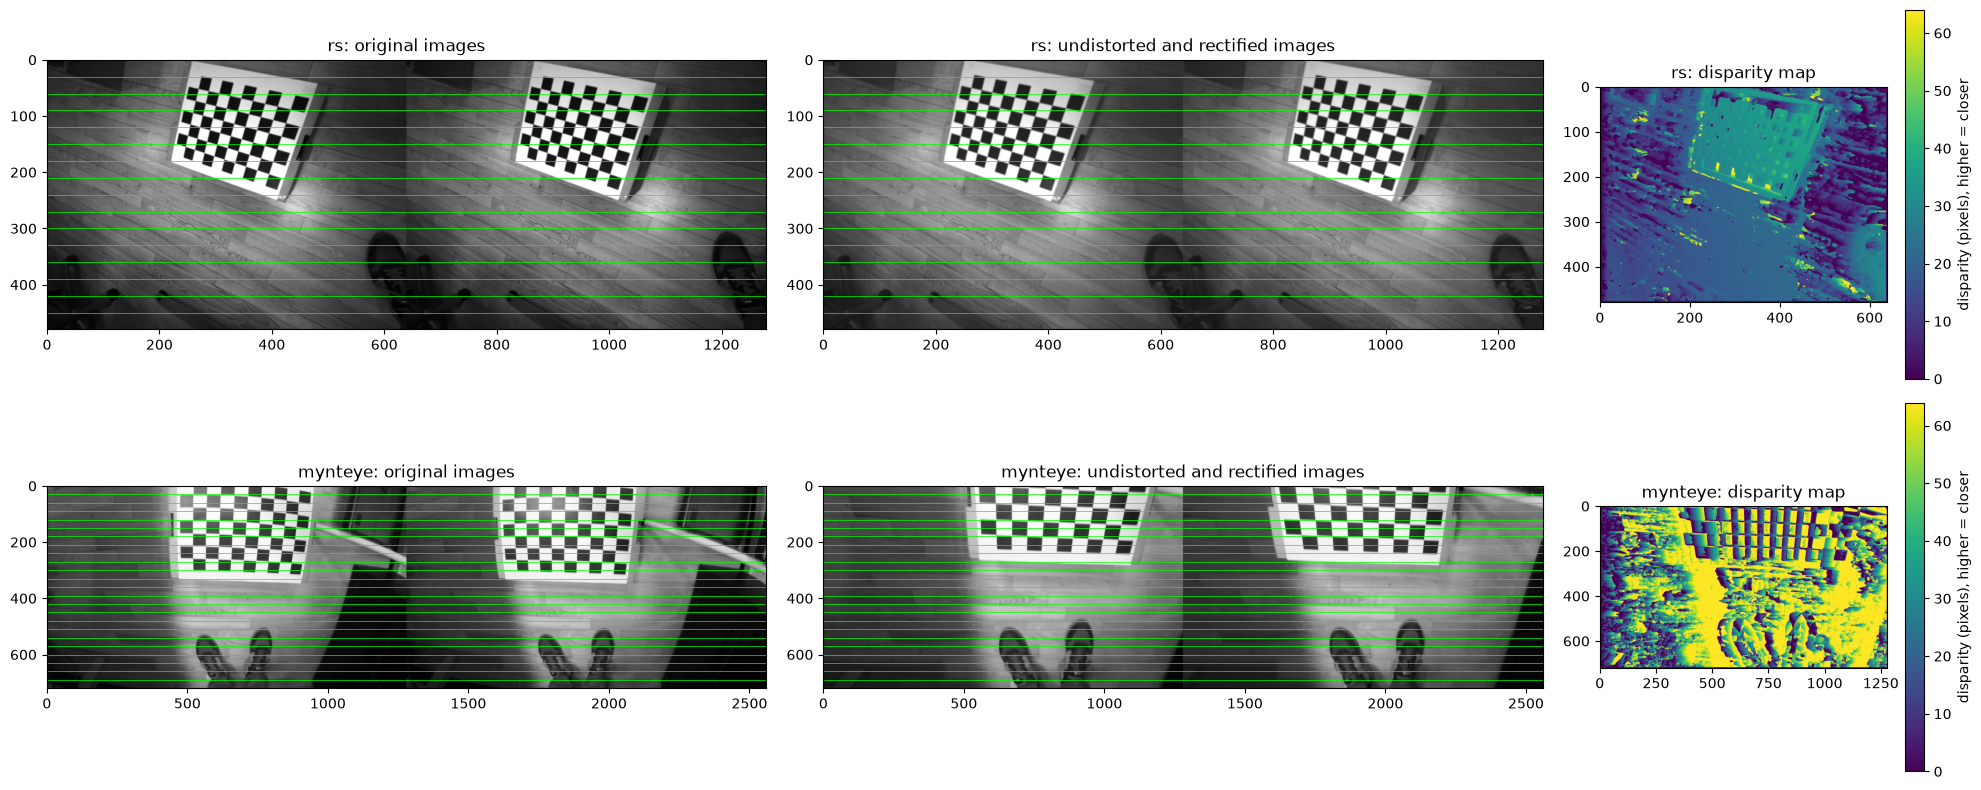

In [16]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 8), gridspec_kw={'width_ratios': [2, 2, 1]})
for row, (dataset, (img_left, img_right, rect_left, rect_right, disparity)) in enumerate(results.items()):
    ax[row, 0].imshow(np.hstack([img_left, img_right]), cmap='gray')
    ax[row, 0].set_title(f'{dataset}: original images')
    ax[row, 1].imshow(np.hstack([rect_left, rect_right]), cmap='gray')
    ax[row, 1].set_title(f'{dataset}: undistorted and rectified images')
    for a in ax[row, :2]:
        for y in range(0, img_left.shape[0], 30):
            a.axhline(y, color='lime', linewidth=0.5)
    im = ax[row, 2].imshow(disparity, cmap='viridis')
    ax[row, 2].set_title(f'{dataset}: disparity map')
    fig.colorbar(im, ax=ax[row, 2], label="disparity (pixels), higher = closer")
plt.tight_layout()
plt.show()

## Declaration of AI Usage

- We used AI to help us refine the code documentation.